## ==================================================
## 🧠 Hopify SaaS: Cohort Retention Curve Decay Plot
## ==================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import DateOffset 

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ===========================================
## 📥 Load & Clean Data
## ===========================================

In [5]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "01_project_churn_retention_analysis",
    "07_hopify_retention_curve_signup_cohort.csv"
)

df = pd.read_csv(file_path)

# 🧼 Clean & Standardize Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.replace("-", "_")
    .str.lower()
)

# ✅ Rename for consistency
df = df.rename(columns={
    'signup_cohort_month': 'signup_cohort',
    'months_since_signup': 'months_since_signup',
    'remaining_active_customers': 'retained_customers',
    'customer_segment': 'customer_segment'
})

## ================================
## 🗓️ Calculate Activity Month
## ================================

In [6]:
df['signup_cohort'] = pd.to_datetime(df['signup_cohort'])
df['activity_month'] = df.apply(
    lambda row: row['signup_cohort'] + DateOffset(months=int(row['months_since_signup'])),
    axis=1
)

# Sort segments for consistent plotting
segment_order = ["Enterprise", "Mid-Market", "SMB"]
df["customer_segment"] = pd.Categorical(df["customer_segment"], categories=segment_order, ordered=True)

## ====================================================
## 📈 Plot Cohort Retention vs Churn Time Series
## ====================================================

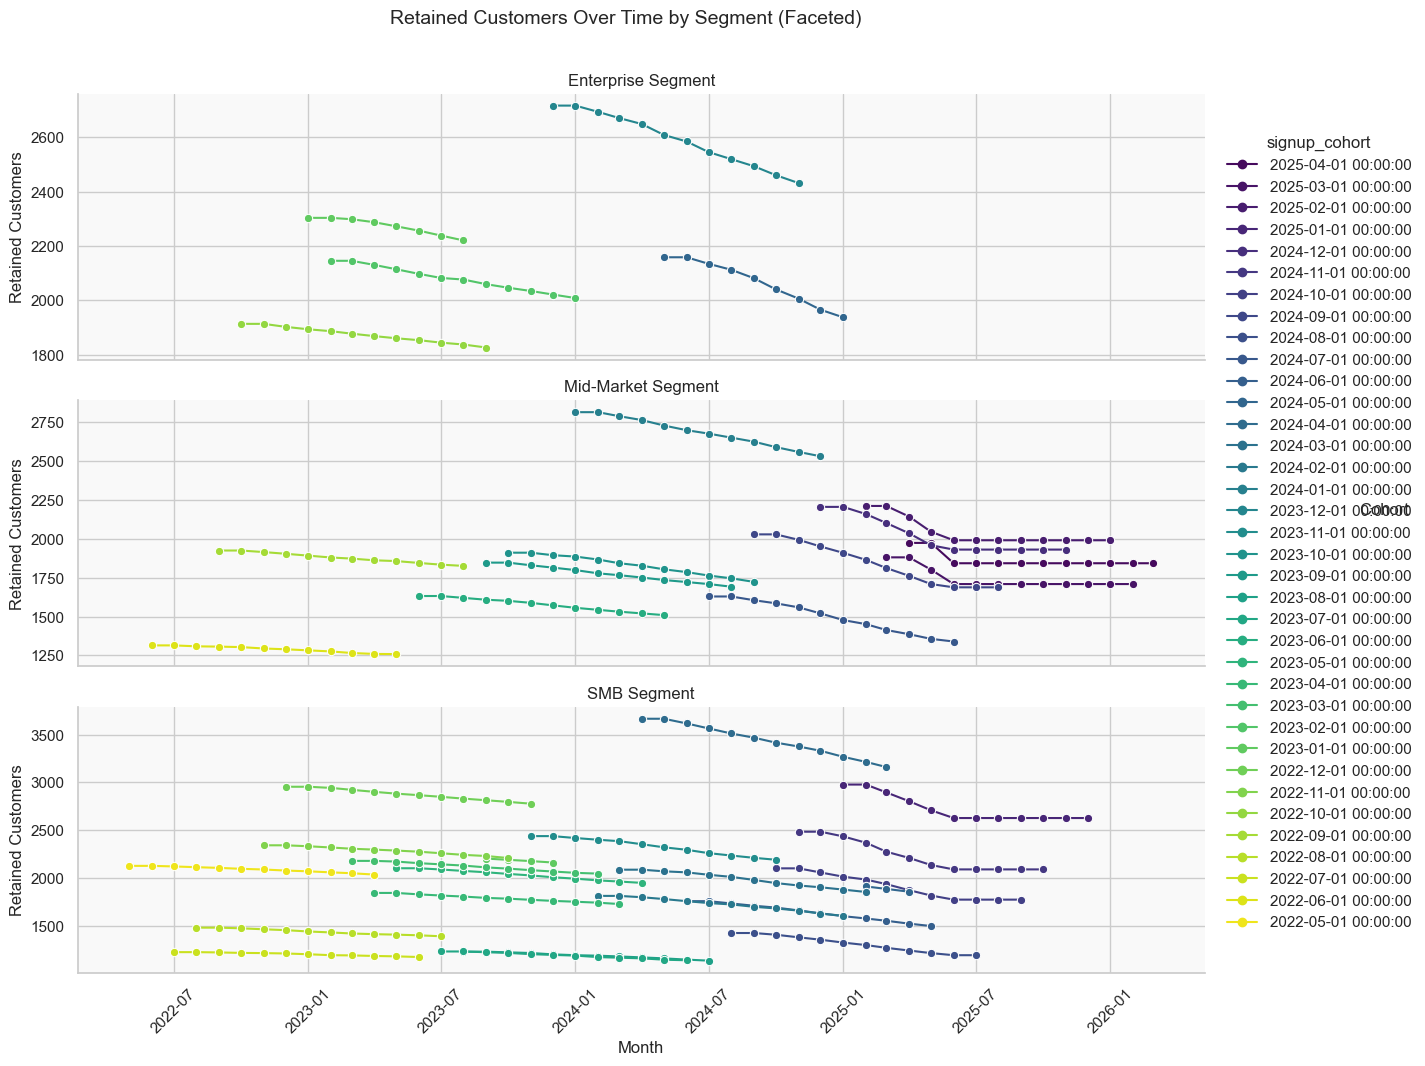

In [7]:
sns.set(style="whitegrid", rc={"axes.facecolor": "#F9F9F9"})
g = sns.relplot(
    data=df,
    kind="line",
    x="activity_month",
    y="retained_customers",
    hue="signup_cohort",
    row="customer_segment",
    marker="o",
    palette="viridis",  # 👈 color accessible
    height=3.5,
    aspect=3,
    facet_kws={"sharey": False}
)

g.set_titles("{row_name} Segment")
g.set_axis_labels("Month", "Retained Customers")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Retained Customers Over Time by Segment (Faceted)", fontsize=14)
g.add_legend(title="Cohort", bbox_to_anchor=(1.05, 0.5), loc='center left')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

## ================================
## 💾 Save & Show
## ================================

In [8]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "hopify_retained_cust_over_time_seg.png"
)

plt.savefig(output_path, bbox_inches='tight', dpi=300)
plt.show()


<Figure size 640x480 with 0 Axes>

## ===========================
## Close Connection
## ===========================

In [9]:
plt.close(BASE_PATH)